# **MNIST**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from tqdm.notebook import tqdm

In [2]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cuda


# Dataset

In [3]:
# Define as tranformações para as imagens
transform = transforms.Compose([
  transforms.ToTensor(),  # Converte imagens para Tensores PyTorch
  transforms.Normalize((0.1307,), (0.3081,))  # Normaliza MNIST médias e std
])

# Carrega dataset de treino
train_dataset = torchvision.datasets.MNIST(
  root="./data",  # Pasta para guardar o dataset
  train=True,     # Marca como dataset de treino
  download=True,  # Faz o download caso não esteja presente
  transform=transform  # Aplica as transformações
)

# Carrega o dataset de teste
test_dataset = torchvision.datasets.MNIST(
  root='./data',
  train=False,
  download=True,
  transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 338kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.88MB/s]


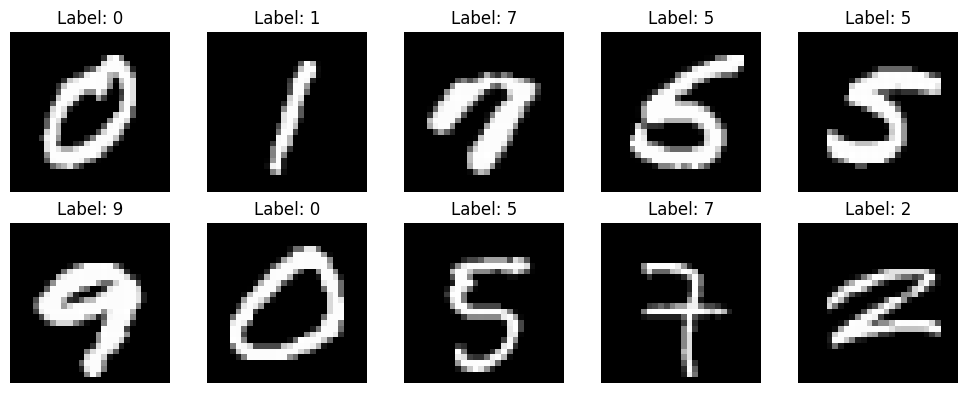

In [4]:
def imshow(images, labels):
  """Função para mostrar imagens."""
  fig, axes = plt.subplots(2, 5, figsize=(10, 4))
  axes = axes.flatten()

  for i in range(10):
    axes[i].imshow(images[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Label: {labels[i]}")
    axes[i].axis('off')

  plt.tight_layout()
  plt.show()

# Pega algumas imagens aleatórias do dataset de treino
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Mostra a imagem
imshow(images[:10], labels[:10])

# Arquitetura

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(28*28, 128)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 10)

  def forward(self, x):
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.fc3(x)
    return x

net = Net().to(device)

# Treinamento

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

In [7]:
# Loop de treinamento
num_epochs = 5
train_losses = []

for epoch in tqdm(range(num_epochs)):
  running_loss = 0.0

  for i, (inputs, labels) in tqdm(enumerate(train_loader), desc=f"Época {epoch+1} Batches", total=len(train_loader)):
    # Trnasfere os tensores para o dispositivo disponível
    inputs, labels = inputs.to(device), labels.to(device)

    # Zera os parâmetros do gradiente
    optimizer.zero_grad()

    # Forward pass
    outputs = net(inputs)
    loss = criterion(outputs, labels)

    # Backward pass e otimização
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    if (i+1) % 100 == 0:
      print(f"[{epoch+1}/{num_epochs}, {i+1}], loss: {running_loss/100:.4f}")
      train_losses.append(running_loss/100)
      running_loss = 0.0

print("Treinamento finalizado!")

  0%|          | 0/5 [00:00<?, ?it/s]

Época 1 Batches:   0%|          | 0/938 [00:00<?, ?it/s]

[1/5, 100], loss: 0.7926
[1/5, 200], loss: 0.1356
[1/5, 300], loss: 0.0920
[1/5, 400], loss: 0.0619
[1/5, 500], loss: 0.0625
[1/5, 600], loss: 0.0585
[1/5, 700], loss: 0.0520
[1/5, 800], loss: 0.0465
[1/5, 900], loss: 0.0459


Época 2 Batches:   0%|          | 0/938 [00:00<?, ?it/s]

[2/5, 100], loss: 0.0208
[2/5, 200], loss: 0.0261
[2/5, 300], loss: 0.0248
[2/5, 400], loss: 0.0263
[2/5, 500], loss: 0.0220
[2/5, 600], loss: 0.0335
[2/5, 700], loss: 0.0292
[2/5, 800], loss: 0.0286
[2/5, 900], loss: 0.0283


...

[3/5, 100], loss: 0.0166
[3/5, 200], loss: 0.0135
[3/5, 300], loss: 0.0090
[3/5, 400], loss: 0.0158
[3/5, 500], loss: 0.0116
[3/5, 600], loss: 0.0168
[3/5, 700], loss: 0.0136
[3/5, 800], loss: 0.0120
[3/5, 900], loss: 0.0157


Época 4 Batches:   0%|          | 0/938 [00:00<?, ?it/s]

[4/5, 100], loss: 0.0108
[4/5, 200], loss: 0.0091
[4/5, 300], loss: 0.0059
[4/5, 400], loss: 0.0079
[4/5, 500], loss: 0.0080
[4/5, 600], loss: 0.0092
[4/5, 700], loss: 0.0056
[4/5, 800], loss: 0.0088
[4/5, 900], loss: 0.0104


Época 5 Batches:   0%|          | 0/938 [00:00<?, ?it/s]

[5/5, 100], loss: 0.0054
[5/5, 200], loss: 0.0052
[5/5, 300], loss: 0.0093
[5/5, 400], loss: 0.0052
[5/5, 500], loss: 0.0082
[5/5, 600], loss: 0.0078
[5/5, 700], loss: 0.0046
[5/5, 800], loss: 0.0037
[5/5, 900], loss: 0.0043
Treinamento finalizado!


# Avaliação

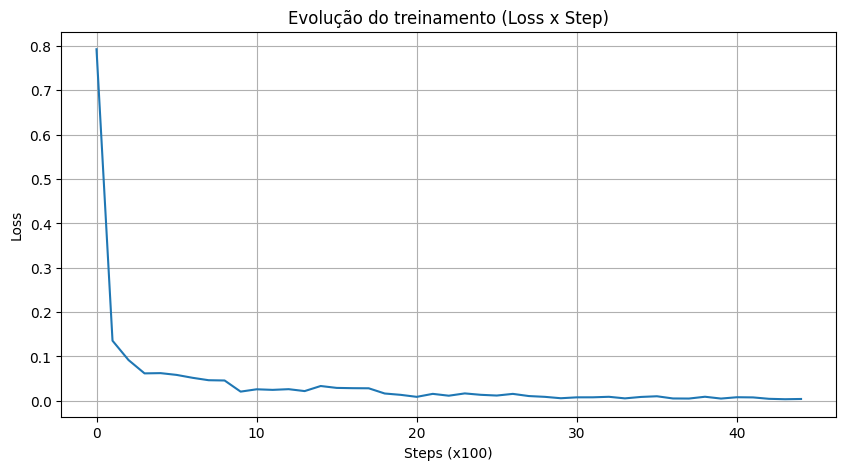

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses)

plt.title("Evolução do treinamento (Loss x Step)")
plt.xlabel("Steps (x100)")
plt.ylabel("Loss")

plt.grid(True)
plt.show()

In [9]:
# Evaluate the model
net.eval().to(device)
correct = 0
total = 0

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = net(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Precisão no dataset de teste: {accuracy:.2f}%")

Precisão no dataset de teste: 99.10%


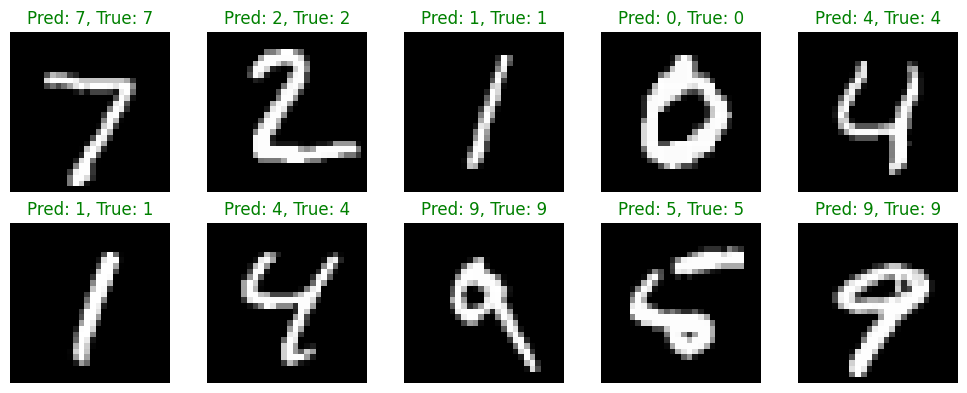

In [10]:
def show_predictions(images, labels, preds):
  """Função para mostrar predições."""
  fig, axes = plt.subplots(2, 5, figsize=(10, 4))
  axes = axes.flatten()

  for i in range(10):
    axes[i].imshow(images[i].cpu().reshape(28, 28), cmap="gray")
    color = "green" if preds[i] == labels[i] else "red"
    axes[i].set_title(f"Pred: {preds[i]}, True: {labels[i]}", color=color)
    axes[i].axis("off")

  plt.tight_layout()
  plt.show()

# Pega algumas imagens de teste.
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = net(images)
_, preds = torch.max(outputs, 1)

# Mostra as predições
show_predictions(images[:10], labels[:10], preds[:10])

# Playground

In [ ]:
from google.colab import output
from IPython.display import HTML, display
import base64
from PIL import Image
import io
import torchvision.transforms as T

# HTML/JS canvas para desenhar e enviar a imagem para o Python
canvas_html = """
<div style="display: flex; flex-direction: column; align-items: center;">
  <h3>Desenhe um dígito (0-9) no quadro abaixo:</h3>
  <canvas id="canvas" width="280" height="280" style="border: 2px solid white; background-color: black; cursor: crosshair;"></canvas>
  <div style="margin-top: 10px;">
    <button onclick="clearCanvas()" style="padding: 8px 16px; margin-right: 10px; cursor: pointer;">Limpar</button>
    <button onclick="predict()" style="padding: 8px 16px; cursor: pointer; background-color: #4CAF50; color: white; border: none;">Predizer</button>
  </div>
</div>

<script>
  const canvas = document.getElementById('canvas');
  const ctx = canvas.getContext('2d');
  ctx.strokeStyle = 'white';
  ctx.lineWidth = 15;
  ctx.lineCap = 'round';
  ctx.lineJoin = 'round';

  let drawing = false;

  canvas.addEventListener('mousedown', (e) => {
    drawing = true;
    ctx.beginPath();
    ctx.moveTo(e.offsetX, e.offsetY);
  });

  canvas.addEventListener('mousemove', (e) => {
    if (drawing) {
      ctx.lineTo(e.offsetX, e.offsetY);
      ctx.stroke();
    }
  });

  canvas.addEventListener('mouseup', () => drawing = false);
  canvas.addEventListener('mouseleave', () => drawing = false);

  function clearCanvas() {
    ctx.clearRect(0, 0, canvas.width, canvas.height);
  }

  function predict() {
    const dataUrl = canvas.toDataURL('image/png');
    google.colab.kernel.invokeFunction('notebook.predict_digit', [dataUrl], {});
  }
</script>
"""

def predict_digit(image_data_url):
  # Remove cabeçalho do Base64
  header, encoded = image_data_url.split(",", 1)
  data = base64.b64decode(encoded)

  # Abre a imagem
  img = Image.open(io.BytesIO(data)).convert("L")

  # Redimensiona para 28x28 com filtro de interpolação antialias
  img_resized = img.resize((28, 28), Image.Resampling.LANCZOS)

  # Processa a imagem para o formato esperado pelo modelo (ToTensor e Normalização idêntica ao transform)
  predict_transform = T.Compose([
      T.ToTensor(),
      T.Normalize((0.1307,), (0.3081,))
  ])

  img_tensor = predict_transform(img_resized).unsqueeze(0).to(device)

  # Predição
  net.eval()
  with torch.no_grad():
    output_logits = net(img_tensor)
    pred = torch.argmax(output_logits, dim=1).item()

  # Mostra o resultado e a imagem reduzida processada
  output.clear(output_tags='prediction_result')
  with output.redirect_to_element('#prediction_result'):
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title("Desenho Original")
    ax[0].axis('off')

    ax[1].imshow(img_resized, cmap='gray')
    ax[1].set_title(f"Model input 28x28")
    ax[1].axis('off')
    plt.show()

    print(f"\nPrediction: O modelo identificou o dígito como: {pred}")

# Registra a função python para ser chamada pelo JS
output.register_callback('notebook.predict_digit', predict_digit)

# Exibe o Canvas e a div reservada para o resultado
display(HTML(canvas_html))
display(HTML('<div id="prediction_result"></div>'))

# CNNs

In [ ]:
class BasicBlock(nn.Module):
  expansion = 1

  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                            stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)

    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                            stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)

    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels * self.expansion:
      self.shortcut = nn.Sequential(
          nn.Conv2d(in_channels, out_channels * self.expansion,
                    kernel_size=1, stride=stride, bias=False),
          nn.BatchNorm2d(out_channels * self.expansion)
      )

  def forward(self, x):
    out = F.relu(self.bn1(self.conv1(x)))
    out = self.bn2(self.conv2(out))
    out += self.shortcut(x)
    out = F.relu(out)
    return out

class ResNet(nn.Module):
  def __init__(self, block, num_blocks, num_classes=10):
    super().__init__()
    self.in_channels = 64

    self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(64)

    self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)   # 28x28
    self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)  # 14x14
    self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)  # 7x7
    self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)  # 4x4

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(512 * block.expansion, num_classes)

    self._initialize_weights()

  def _make_layer(self, block, out_channels, num_blocks, stride):
    strides = [stride] + [1] * (num_blocks - 1)
    layers = []
    for s in strides:
        layers.append(block(self.in_channels, out_channels, s))
        self.in_channels = out_channels * block.expansion
    return nn.Sequential(*layers)

  def _initialize_weights(self):
    for m in self.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)

  def forward(self, x):
    out = F.relu(self.bn1(self.conv1(x)))
    out = self.layer1(out)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.layer4(out)
    out = self.avgpool(out)
    out = torch.flatten(out, 1)
    out = self.fc(out)
    return out

net = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10).to(device)
print(net)

ConvNet(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.25, inplace